In [ ]:
#LDA_analysis
  #Linear Discriminant Analysis/ supervised dimensionality reduction(PCA is unsupervised dimensionality reduction)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [8]:
data = load_breast_cancer()
x = pd.DataFrame( data.data , columns = data.feature_names)
y = pd.Series(data.target)
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
#check dimensions
print("number of rows:", x.shape[0])
print("number of features:", x.shape[1])
print (" number of classes:" , y.nunique())

number of rows: 569
number of features: 30
 number of classes: 2


In [17]:
#standardize the data
# Without scaling, features with larger numerical values could have a disproportionate effect.
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [19]:
#LDA
#Because dataset has 2 different classes, LDA can produce at most: Number of classes - 1 = 1 components.
lda = LinearDiscriminantAnalysis(n_components = 1)
x_lda = lda.fit_transform(x_scaled , y)
lda.fit_transform(x_scaled, y)

array([[-3.32392717e+00],
       [-2.31910801e+00],
       [-3.74742484e+00],
       [-4.04854946e+00],
       [-2.28115767e+00],
       [-1.61150348e+00],
       [-2.35653128e+00],
       [-1.28122316e+00],
       [-1.60828074e+00],
       [-3.86266690e+00],
       [-8.64980964e-01],
       [-2.39981887e+00],
       [-1.32670638e+00],
       [-4.20145181e-01],
       [-1.25084871e+00],
       [-3.06625368e+00],
       [-2.11049829e+00],
       [-3.17780841e+00],
       [-3.43796946e+00],
       [ 2.23125867e-01],
       [ 1.97973275e+00],
       [ 2.46635453e+00],
       [-1.79100127e+00],
       [-3.02554197e+00],
       [-3.87178737e+00],
       [-3.99524140e+00],
       [-2.74537482e+00],
       [-2.57652189e+00],
       [-3.07566630e+00],
       [-8.02258881e-01],
       [-3.41613522e+00],
       [-2.67943316e+00],
       [-3.63987363e+00],
       [-3.07550539e+00],
       [-2.68840028e+00],
       [-2.57312945e+00],
       [-1.07380321e+00],
       [ 1.87492316e+00],
       [ 4.9

In [21]:
print("Original shape:", x.shape)
print("LDA shape:", x_lda.shape)
#30 features → 1 feature

Original shape: (569, 30)
LDA shape: (569, 1)


In [23]:
# create dataframe with new one feature
lda_df = pd.DataFrame(x_lda , columns = ["LD1"])
lda_df["target"] = y.values
lda_df.head()

,LD1,target
0,-3.323927,0
1,-2.319108,0
2,-3.747425,0
3,-4.048549,0
4,-2.281158,0


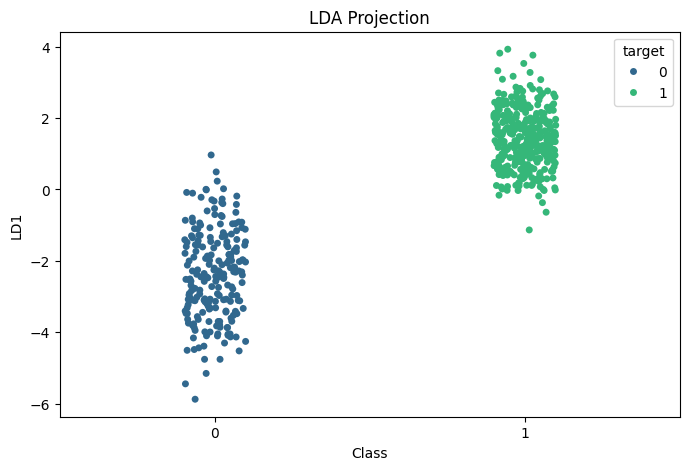

In [25]:
#Visualize LDA

plt.figure(figsize=(8,5))
sns.stripplot(
    data = lda_df,
    x ="target",
    y = "LD1",
    hue = "target",
    palette = "viridis",
)


plt.title("LDA Projection")
plt.xlabel("Class")
plt.ylabel("LD1")

plt.show()

In [26]:
# LDA Coefficients (which original features contribute to the discriminant)
lda.coef_

array([[ 1.44833568e+01, -3.68957962e-01, -1.08865782e+01,
        -2.11087855e+00, -2.24784150e-02,  4.20809820e+00,
        -2.10328313e+00, -1.56846323e+00, -5.31387551e-02,
        -4.43195602e-03, -2.27635626e+00,  7.03616573e-02,
         8.59307158e-01,  7.92601536e-01, -8.98376566e-01,
        -2.19353267e-02,  2.03117873e+00, -1.23061216e+00,
        -2.64794590e-01,  3.56875236e-01, -1.78035220e+01,
        -8.30445328e-01,  1.54420617e+00,  1.08656797e+01,
        -2.33917449e-01, -1.99413370e-01, -1.50083483e+00,
        -5.75986366e-01, -6.50095283e-01, -1.46687628e+00]])

In [30]:
lda_coefficients = pd.DataFrame(
    lda.coef_.T,
    index = x.columns,
    columns = ["LD1"]
)

lda_coefficients.sort_values(
    by="LD1",
    ascending=False
)
#for example mean radius contribute to LDA in positive direction.

,LD1
mean radius,14.483357
worst area,10.865680
mean compactness,4.208098
concavity error,2.031179
worst perimeter,1.544206
perimeter error,0.859307
area error,0.792602
fractal dimension error,0.356875
texture error,0.070362
mean fractal dimension,-0.004432
